# [drosophila_body_orientation_predictor](https://github.com/nehalsinghmangat/drosophila_body_orientation_predictor) — Data Pipeline

This notebook cleans, corrects, and augments the experimental data from [van Breugel et al. (2014)](https://www.sciencedirect.com/science/article/pii/S0960982213015820) to produce the fully preprocessed dataset used to train the heading predictor neural network.

The pipeline proceeds through the following stages, saving intermediate outputs to `../pipelinedata/`:

1. **`01_merged/`** — Raw Parquet files merged across wind speeds (30/40/60 cm/s)
2. **`02_augmented/`** — Kinematic features added (groundspeed, airspeed, thrust, acceleration)
3. **`03_corrected/`** — 180° heading ambiguities resolved via naïve + convex-optimisation correction
4. **`04_filtered/`** — Short or uncorrectable trajectories removed
5. **`05_smoothed/`** — Residual jitter suppressed with Savitzky–Golay smoothing
6. **`06_final/`** — Output columns (`heading_angle_x`, `heading_angle_y`) added; ready for model training

Neural network training is handled in the companion notebook `model_training.ipynb`.

## Methods


### Data Preparation and Preprocessing

We use data from [van Breugel et al. (2014)](https://doi.org/10.1242/jeb.098665), collected across three constant-wind conditions (30, 40, 60 cm/s). Two data streams are merged per trajectory: (i) flight trajectory (x/y position and velocity) and (ii) body-orientation measurements captured as ellipse parameters. Trajectories shorter than a minimum duration are discarded to ensure adequate temporal context for model training.

Below, we load the raw Parquet files for each wind speed, correct the airspeed reference frame, standardize field names, synchronize timestamps, and merge the two streams into a single CSV per wind speed.

In [ ]:
import os
import sys
import pandas as pd
import datetime

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    correct_for_wind,
    remove_irrelevant_trajectory_data,
    remove_irrelevant_body_data,
    sync_time,
    join_all_body_and_trajec_df,
    transform_timestamps_to_start_at_zero,
)

In [ ]:

windspeeds = ["30cms", "40cms", "60cms"]
for windspeed in windspeeds:
    trajec_df = pd.read_parquet(f"../experimentaldata/{windspeed}/flight_trajectories_3d_HCS_odor_horizon_matched.parquet")
    body_df = pd.read_parquet(f"../experimentaldata/{windspeed}/body_orientations_HCS_odor_horizon_matched.parquet")
    key_table = pd.read_parquet(f"../experimentaldata/{windspeed}/body_trajec_matches.parquet")

    trajec_df = correct_for_wind(trajec_df)
    trajec_df = remove_irrelevant_trajectory_data(trajec_df)
    body_df = remove_irrelevant_body_data(body_df)

    synced_trajectory = sync_time(trajec_df)
    synced_body = sync_time(body_df)

    body_and_trajectory = join_all_body_and_trajec_df(synced_body, synced_trajectory, key_table)
    body_and_trajectory = [transform_timestamps_to_start_at_zero(t) for t in body_and_trajectory]
    body_and_trajectory = [t for t in body_and_trajectory if len(t) > 12]

    temp_fly_data = pd.concat(body_and_trajectory, ignore_index=True)
    os.makedirs(f"../pipelinedata/01_merged/{windspeed}", exist_ok=True)
    temp_fly_data.to_csv(f"../pipelinedata/01_merged/{windspeed}/fly_trajectories_with_body_orientations.csv", index=False)

temp_file_paths = [
    "../pipelinedata/01_merged/30cms/fly_trajectories_with_body_orientations.csv",
    "../pipelinedata/01_merged/40cms/fly_trajectories_with_body_orientations.csv",
    "../pipelinedata/01_merged/60cms/fly_trajectories_with_body_orientations.csv",
]
temp_dfs = [pd.read_csv(f) for f in temp_file_paths]
heading_and_trajectories = pd.concat(temp_dfs, ignore_index=True)
heading_and_trajectories.to_csv('../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv', index=False)

Visualize the data

In [ ]:
all_fly_data = pd.read_csv('../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv')
all_fly_data.head()

#### Kinematic Feature Augmentation

We augment each merged trajectory with physically meaningful derived quantities: groundspeed, airspeed, linear acceleration, and thrust (magnitude and angle). These fields are required both for heading correction (thrust angle serves as a reference direction) and as inputs to the neural network. The heading angle is also initialized here from the ellipse short-axis angle (accurate only modulo π — corrected in the next step).


In [ ]:
import os
import pynumdiff as pynd
import numpy as np

from utils import augment_fly_trajectory

In [ ]:
all_fly_data = pd.read_csv('../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv')
body_and_trajectory_by_id = [group for _, group in all_fly_data.groupby('trajec_objid')]

temp_augmented_all_fly_data = [augment_fly_trajectory(df, compute_heading_from_ellipses=True) for df in body_and_trajectory_by_id]
augmented_all_fly_data = pd.concat(temp_augmented_all_fly_data, ignore_index=True)
os.makedirs('../pipelinedata/02_augmented', exist_ok=True)
augmented_all_fly_data.to_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv', index=False)

#### Body Orientation Correction and Filtering

The body-orientation measurements were captured with a top-down camera. At each frame, the fly was approximated as an ellipse, so the recorded heading is only accurate modulo π. This produces discontinuous π-jumps throughout many trajectories. Measurement noise also introduces high-frequency jitter.

We apply three sequential steps to correct and smooth the heading signal before use in training.


##### 1. Naïve Heading Correction

A simple heuristic exploiting two behavioral observations: (1) *Drosophila* generally fly with their body axis aligned with the thrust vector, and (2) at the temporal resolution of these measurements (0.01 s), the fly rarely changes heading by more than π/2.

The initial orientation is aligned with the thrust direction, then `np.unwrap` with `period=π` detects and removes subsequent π-flips. This resolves most ambiguities but fails for some dynamic segments — motivating the convex-optimization step below.


In [ ]:
import scipy

from utils import naive_heading_correction

##### 2. Convex-Optimization–Based Heading Correction

To obtain a globally consistent heading signal, we solve a mixed-integer convex program. At each time step $t$, we select $k_t \in \{-1, 0, 1\}$ to add $k_t \pi$ to the raw measurement $\theta_t$, minimizing:

$$\min_{\{k_t\}} \; \alpha_1 \sum_{t=2}^T |\tilde\theta_t - \tilde\theta_{t-1}| + \alpha_2 \sum_{t=1}^T \frac{f_t}{\bar{f}} |\tilde\theta_t - \varphi_t|$$

where $\tilde\theta_t = \theta_t^{\text{unwrapped}} + k_t\pi$, $\varphi_t$ is the thrust direction, and $f_t / \bar{f}$ is the normalised thrust magnitude. The heading is unwrapped via `np.unwrap` before entering the optimisation so that the total-variation term correctly measures angular change across the $\pm\pi$ boundary. The thrust-magnitude weighting ensures that alignment to the thrust direction is enforced most strongly during high-force dynamic manoeuvres. Solved via `cvxpy` with the MOSEK solver.

In [ ]:
import cvxpy

from utils import convex_opt_heading_correction

##### Visualizing Heading Correction Steps

For troubleshooting and sanity-checking, we visualize a sample of trajectories at each correction stage to confirm the algorithm is behaving as expected.


In [ ]:
import os
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
heading_and_trajectory_by_id = [group for _, group in augmented_all_fly_data.groupby('trajec_objid')]

In [ ]:
from utils import plot_trajectory

In [ ]:
import random
import gc

# Set the random seed for repeatability
random.seed(42)

# Randomly sample 100 trajectories from heading_and_trajectory_by_id
sampled_trajectories = random.sample(heading_and_trajectory_by_id, 100)

# Loop through each trajectory and create/save figures
for trajectory in sampled_trajectories:
    trajec_objid = trajectory["trajec_objid"].iloc[0]

    # Create the subplots with a reduced dpi and adjusted size
    fig, axs = plt.subplots(1, 3, figsize=(10, 10), dpi=100)

    # Plot the original trajectory
    plot_trajectory(axs[0], trajectory)

    # Apply the naive heading correction once, store the result
    naive_correction = naive_heading_correction(trajectory)
    plot_trajectory(axs[1], naive_correction)

    # Apply the convex optimization correction and plot
    convex_correction = convex_opt_heading_correction(naive_correction)
    plot_trajectory(axs[2], convex_correction)

    # Save the figure as an SVG file
    os.makedirs('../pipelinedata/03_corrected/heading_correction_steps_svg', exist_ok=True)
    svg_filename = f'../pipelinedata/03_corrected/heading_correction_steps_svg/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')

    # Close the figure to free up memory
    plt.close(fig)

    # Explicitly call garbage collection to free memory
    gc.collect()

In [ ]:
# plot specific trajectory by id
test_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"]=="20130325_193727_8614"]
fig, axs = plt.subplots(1, 2, figsize=(12, 12), dpi=150)
plot_trajectory(axs[0],test_trajec)
plot_trajectory(axs[1],convex_opt_heading_correction(naive_heading_correction(test_trajec)))
plt.show()

##### Applying Heading Correction to All Trajectories

We apply both correction algorithms sequentially to every trajectory and save the result.


In [ ]:
import os

augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
body_and_trajectory_by_id = [group for _, group in augmented_all_fly_data.groupby('trajec_objid')]
temp_dfs = []
for traj in body_and_trajectory_by_id:
    corrected_trajec = convex_opt_heading_correction(naive_heading_correction(traj))
    temp_dfs.append(corrected_trajec)
corrected_aug_all_fly_data = pd.concat(temp_dfs, ignore_index=True)
os.makedirs('../pipelinedata/03_corrected', exist_ok=True)
corrected_aug_all_fly_data.to_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv', index=False)

##### Trajectory Filtering

Some trajectories retain residual π-flips that neither correction step fully resolves. We detect these by computing the circular distance between consecutive heading angles and filtering out trajectories that exceed a threshold jump magnitude.


In [ ]:
from utils import circular_distance, calc_circular_difference

In [ ]:
import os

# Load the CSV file
corrected_aug_all_fly_data = pd.read_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv')

# Group data by 'trajec_objid'
body_and_trajectory_by_id = [group for _, group in corrected_aug_all_fly_data.groupby('trajec_objid')]

# Initialize lists for storing filtered and removed trajectories
temp_dfs = []
temp_bad_dfs = []
removal_count = 0

# Loop through each trajectory and apply filtering based on circular difference
for traj in body_and_trajectory_by_id:
   circ_diff_data = calc_circular_difference(traj)  # Ensure this function returns a DataFrame with 'circ_dist_diff'
   if max(circ_diff_data["circ_dist_diff"]) < (np.pi / 2):  # Filter condition
      temp_dfs.append(traj)  # Keep this trajectory
   else:
      temp_bad_dfs.append(traj)  # Mark this trajectory for removal
      removal_count += 1

# Concatenate the filtered and removed trajectories into separate DataFrames
bad_all_fly_data = pd.concat(temp_bad_dfs, ignore_index=True)
filtered_corr_aug_all_fly_data = pd.concat(temp_dfs, ignore_index=True)

os.makedirs('../pipelinedata/04_filtered', exist_ok=True)

# Save the filtered data to CSV files
filtered_corr_aug_all_fly_data.to_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv', index=False)

# Save the rejected trajectories
bad_all_fly_data.to_csv('../pipelinedata/04_filtered/rejected_trajectories.csv', index=False)

# Print the total number of trajectories and the number of removals
print(f"Total trajectories: {len(body_and_trajectory_by_id)}")
print(f"Number of removed trajectories: {removal_count}")

##### Visualizing Filtered-Out Trajectories


In [ ]:
import random
import gc

rejected_trajectories = pd.read_csv('../pipelinedata/04_filtered/rejected_trajectories.csv')
body_and_trajectory_by_id = [group for _, group in rejected_trajectories.groupby('trajec_objid')]

# Set the random seed for repeatability
random.seed(42)

# Loop through each trajectory and create/save figures
for trajectory in body_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

    plot_trajectory(ax, trajectory, plot_ellipses=False, every_nth=1)

    # Save the figure as an SVG file
    os.makedirs('../pipelinedata/04_filtered/rejected_trajectory_svgs', exist_ok=True)
    svg_filename = f'../pipelinedata/04_filtered/rejected_trajectory_svgs/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)  # Close the figure to free up memory
    gc.collect()

In [ ]:
rejected_trajectories = pd.read_csv('../pipelinedata/04_filtered/rejected_trajectories.csv')
body_and_trajectory_by_id = [group for _, group in rejected_trajectories.groupby('trajec_objid')]
bad_trajec_1 = rejected_trajectories.loc[rejected_trajectories["trajec_objid"]=="20121002_184808_1788"]
fig, axs = plt.subplots(1, 3, figsize=(12, 12), dpi=150)
plot_trajectory(axs[0],bad_trajec_1)
plot_trajectory(axs[1],bad_trajec_1)
plot_trajectory(axs[2],bad_trajec_1)
plt.show()

##### 3. Temporal Smoothing

To reduce measurement jitter, we apply a two-stage procedure. First, the corrected heading is unwrapped to a continuous signal using a sliding-window algorithm that selects the 2π-shifted representative most consistent with recent history. Second, the unwrapped signal is smoothed with a Savitzky–Golay filter (sampling interval 0.01 s) to suppress high-frequency noise while retaining slower turning dynamics. The result is wrapped back to [−π, π] and used as the training target.


This is especially noticeable in downwind trajectories, where the fly's heading can drift slowly relative to its velocity direction.


In [ ]:
from utils import smooth_trajectory

In [ ]:
test_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"]=="20121002_184808_5511"]
fig, axs = plt.subplots(1, 2, figsize=(12, 12), dpi=150)
plot_trajectory(axs[0],convex_opt_heading_correction(naive_heading_correction(test_trajec)),plot_ellipses=False,every_nth=1,legend=False)
plot_trajectory(axs[1],smooth_trajectory(convex_opt_heading_correction(naive_heading_correction(test_trajec))),plot_ellipses=False,every_nth=1,legend=False)

##### Applying Smoothing to All Trajectories


In [ ]:
import os

filtered_aug_all_fly_data = pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')
body_and_trajectory_by_id = [group for _, group in filtered_aug_all_fly_data.groupby('trajec_objid')]
temp_dfs = []
test_dfs = []
for traj in body_and_trajectory_by_id:
    test_dfs.append(traj)
    smoothed_trajec = smooth_trajectory(traj)
    temp_dfs.append(smoothed_trajec)
smoothed_corrected_aug_all_fly_data = pd.concat(temp_dfs, ignore_index=True)
os.makedirs('../pipelinedata/05_smoothed', exist_ok=True)
smoothed_corrected_aug_all_fly_data.to_csv('../pipelinedata/05_smoothed/all_wind_heading_and_trajectories_augmented_corrected_filtered_smoothed.csv', index=False)

##### Visualizing Smoothed Trajectories


In [ ]:
smoothed_all_fly_data = pd.read_csv('../pipelinedata/05_smoothed/all_wind_heading_and_trajectories_augmented_corrected_filtered_smoothed.csv')
body_and_trajectory_by_id = [group for _, group in smoothed_all_fly_data.groupby('trajec_objid')]

In [ ]:
import random
import gc

# Set the random seed for repeatability
random.seed(42)

# Randomly sample 100 trajectories from heading_and_trajectory_by_id
sampled_trajectories = random.sample(body_and_trajectory_by_id, 100)

# Loop through each trajectory and create/save figures
for trajectory in sampled_trajectories:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

    plot_trajectory(ax, trajectory)

    # Save the figure as an SVG file
    os.makedirs('../pipelinedata/05_smoothed/trajectory_svgs', exist_ok=True)
    svg_filename = f'../pipelinedata/05_smoothed/trajectory_svgs/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)  # Close the figure to free up memory
    gc.collect()

##### Figure 1 Panel A

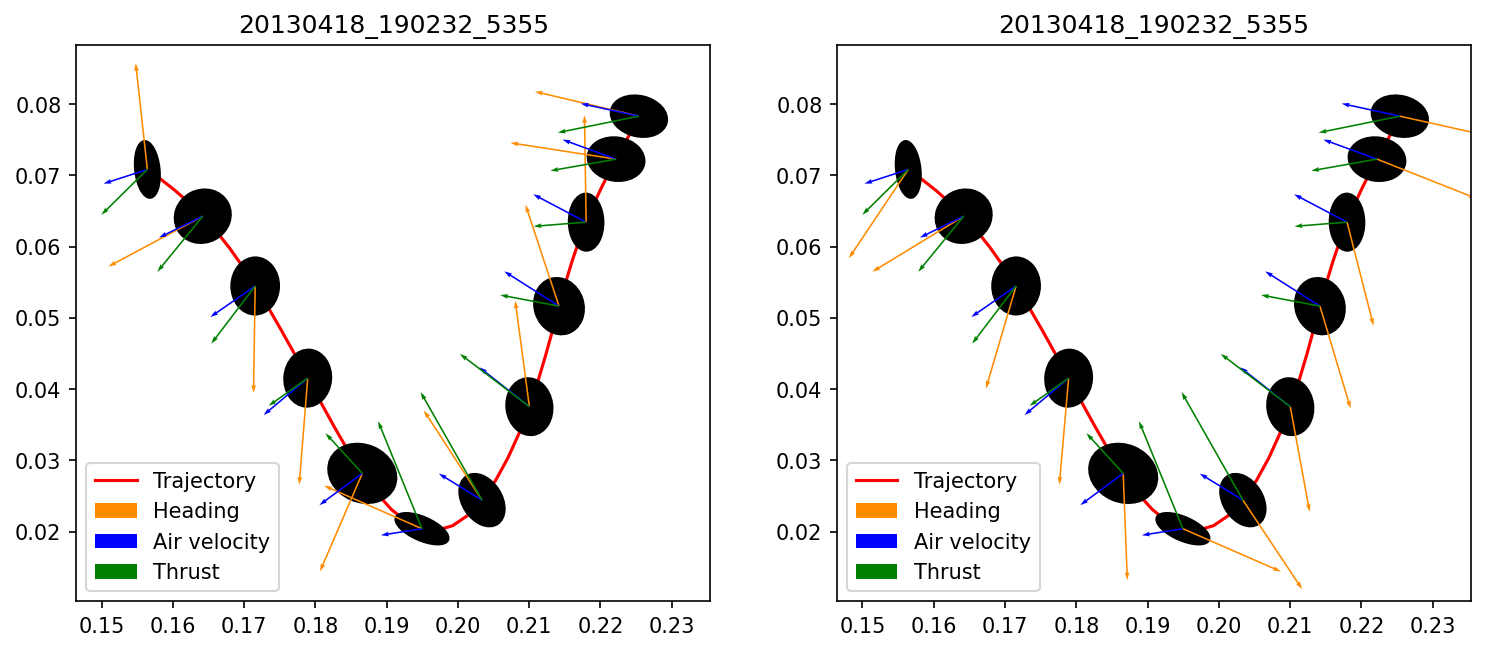

In [ ]:
# plot specific trajectory by id
test_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"]=="20130418_190232_5355"]
corr_trajec = smoothed_all_fly_data.loc[smoothed_all_fly_data["trajec_objid"]=="20130418_190232_5355"]
fig, axs = plt.subplots(1, 2, figsize=(12, 12), dpi=150)

plot_trajectory(axs[0],test_trajec)
plot_trajectory(axs[1],corr_trajec)

fig.savefig('../figures/fig_1_panel_A.pdf', format='pdf', bbox_inches='tight')
plt.show()

##### Figure 1 Panel B

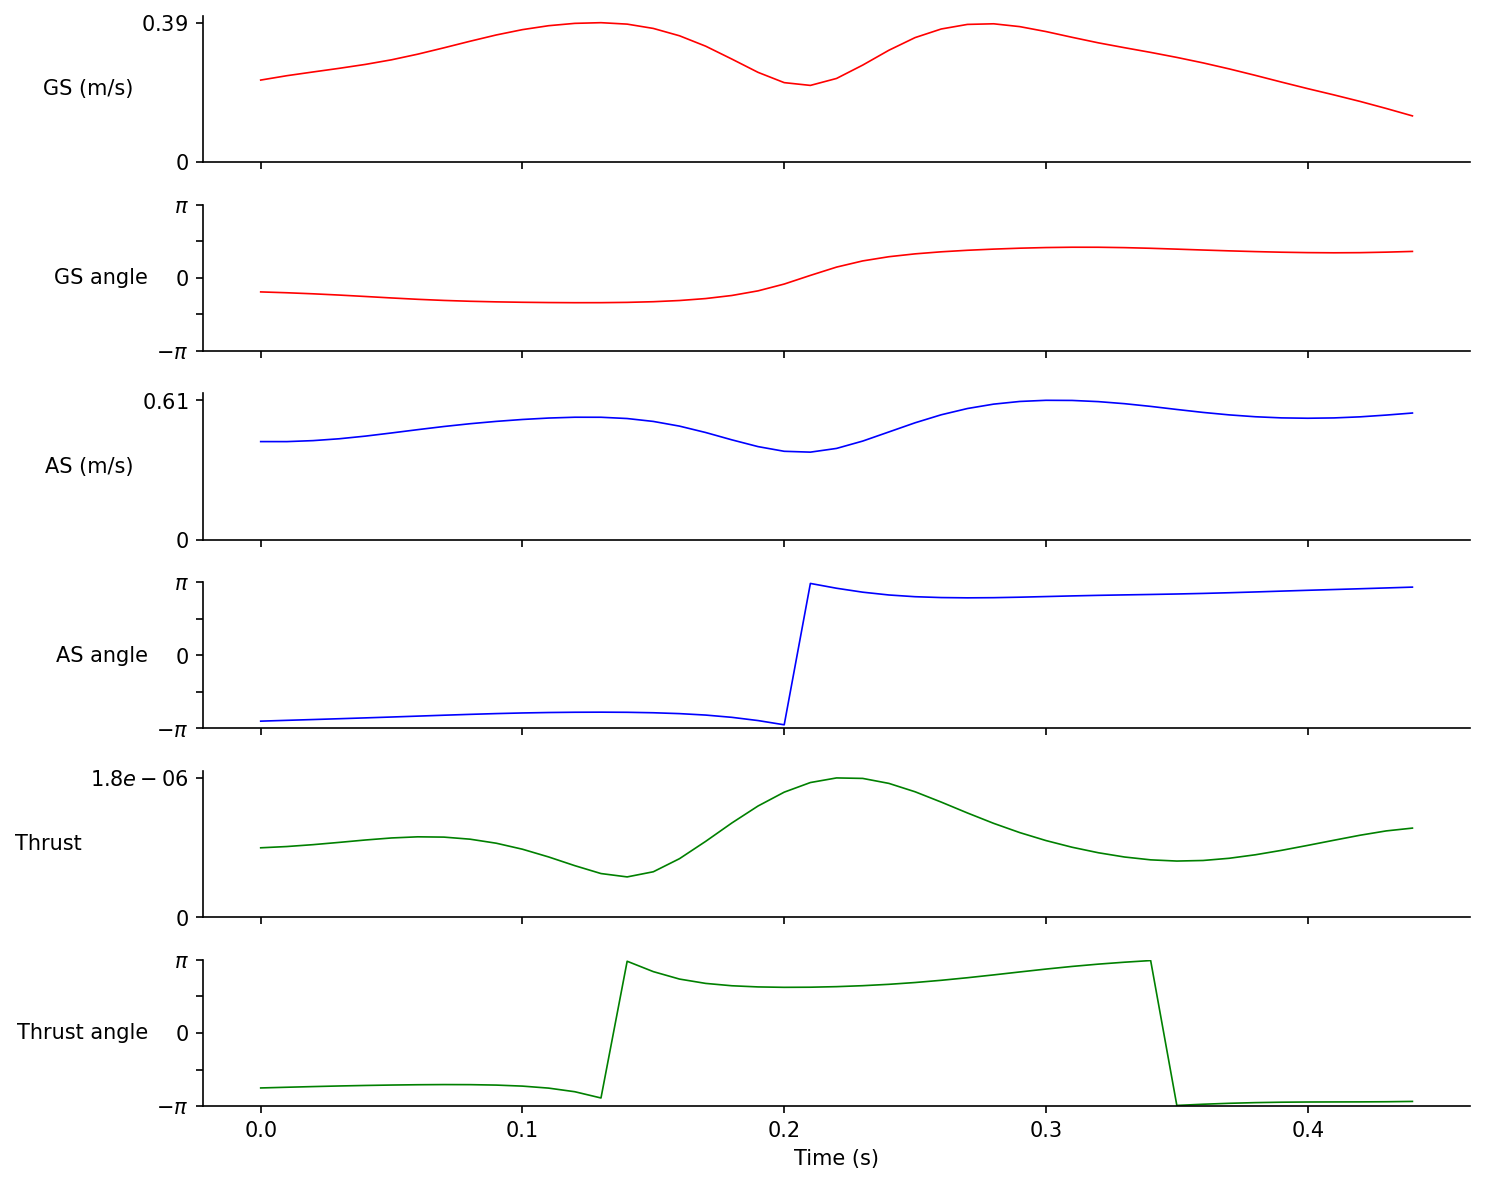

In [ ]:
from utils import plot_fly_inputs_stacked

panel_b_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"]=="20130418_190232_5355"]

fig, axes = plt.subplots(6, 1, figsize=(10, 8), dpi=150, sharex=True)
plot_fly_inputs_stacked(panel_b_trajec, axes=axes)
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_1_panel_B.pdf', format='pdf', bbox_inches='tight')
plt.show()

##### Figure 1 Panel C

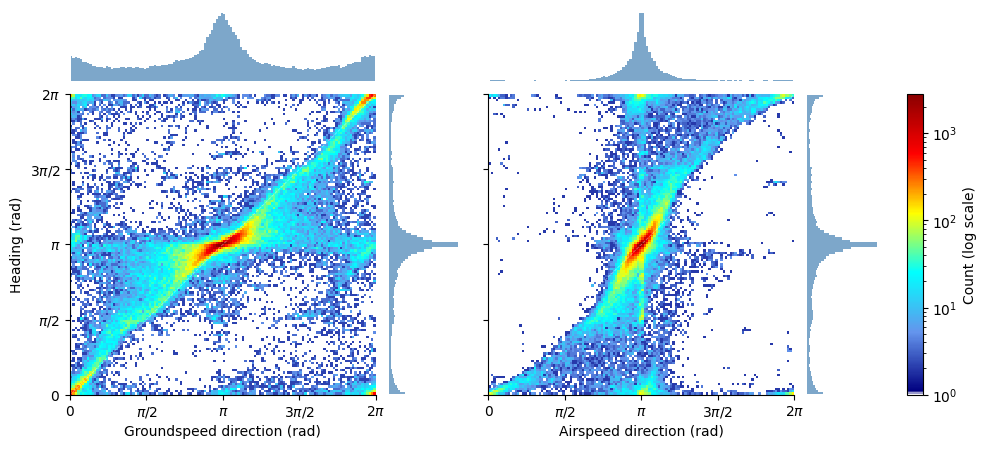

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from utils import make_color_map

heading  = smoothed_all_fly_data['heading_angle'].values
gs_angle = smoothed_all_fly_data['groundspeed_angle'].values
as_angle = smoothed_all_fly_data['airspeed_angle'].values

cmap = make_color_map(color_list=['white', 'navy', 'cornflowerblue', 'aqua', 'yellow', 'red', 'darkred'], N=256)

PI_TICKS  = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
PI_LABELS = [r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']

def wrap_to_2pi(a):
    return a % (2 * np.pi)

def plot_scatter_heatmap_with_marginals(ax_main, ax_top, ax_right, x_data, y_data,
                                        x_label, y_label, n_bins=128, cmap=None,
                                        show_ylabel=True):
    if cmap is None:
        cmap = make_color_map(color_list=['white', 'navy', 'cornflowerblue', 'aqua', 'yellow', 'red', 'darkred'], N=256)
    x_data = wrap_to_2pi(x_data)
    y_data = wrap_to_2pi(y_data)
    angle_range = [[0, 2*np.pi], [0, 2*np.pi]]
    h, xedges, yedges = np.histogram2d(x_data, y_data, bins=n_bins, range=angle_range)
    h_masked = np.ma.masked_where(h.T == 0, h.T)
    norm = mcolors.LogNorm(vmin=1, vmax=h.max())
    im = ax_main.pcolormesh(xedges, yedges, h_masked, norm=norm, cmap=cmap)
    ax_main.plot([0, 2*np.pi], [0, 2*np.pi], 'w--', lw=0.6, alpha=0.4)
    ax_main.set_xlim(0, 2*np.pi)
    ax_main.set_ylim(0, 2*np.pi)
    ax_main.set_xticks(PI_TICKS)
    ax_main.set_xticklabels(PI_LABELS)
    ax_main.set_yticks(PI_TICKS)
    ax_main.set_yticklabels(PI_LABELS if show_ylabel else ['']*len(PI_TICKS))
    ax_main.set_xlabel(x_label, fontsize=10)
    if show_ylabel:
        ax_main.set_ylabel(y_label, fontsize=10)
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    x_counts, x_bin_edges = np.histogram(x_data, bins=n_bins, range=(0, 2*np.pi))
    x_centers = 0.5 * (x_bin_edges[:-1] + x_bin_edges[1:])
    ax_top.fill_between(x_centers, x_counts, step='mid', color='steelblue', alpha=0.7, lw=0)
    ax_top.set_xlim(0, 2*np.pi)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    for spine in ax_top.spines.values():
        spine.set_visible(False)
    y_counts, y_bin_edges = np.histogram(y_data, bins=n_bins, range=(0, 2*np.pi))
    y_centers = 0.5 * (y_bin_edges[:-1] + y_bin_edges[1:])
    ax_right.fill_betweenx(y_centers, y_counts, step='mid', color='steelblue', alpha=0.7, lw=0)
    ax_right.set_ylim(0, 2*np.pi)
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    for spine in ax_right.spines.values():
        spine.set_visible(False)
    return im

fig = plt.figure(figsize=(11, 5))
outer = gridspec.GridSpec(1, 3, figure=fig, wspace=0.1, width_ratios=[10, 10, 0.4])

gs1 = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0],
    width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)
ax1_top   = fig.add_subplot(gs1[0, 0])
ax1_main  = fig.add_subplot(gs1[1, 0])
ax1_right = fig.add_subplot(gs1[1, 1])
fig.add_subplot(gs1[0, 1]).axis('off')

gs2 = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[1],
    width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)
ax2_top   = fig.add_subplot(gs2[0, 0])
ax2_main  = fig.add_subplot(gs2[1, 0])
ax2_right = fig.add_subplot(gs2[1, 1])
fig.add_subplot(gs2[0, 1]).axis('off')

gs_cbar = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[2],
    height_ratios=[1, 4], hspace=0.05)
ax_cbar = fig.add_subplot(gs_cbar[1, 0])

im1 = plot_scatter_heatmap_with_marginals(
    ax1_main, ax1_top, ax1_right,
    gs_angle, heading,
    'Groundspeed direction (rad)', 'Heading (rad)', cmap=cmap, show_ylabel=True)

im2 = plot_scatter_heatmap_with_marginals(
    ax2_main, ax2_top, ax2_right,
    as_angle, heading,
    'Airspeed direction (rad)', 'Heading (rad)', cmap=cmap, show_ylabel=False)

cbar = fig.colorbar(im2, cax=ax_cbar, label='Count (log scale)')
cbar.ax.yaxis.label.set_size(10)

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_1_panel_C.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

### Feature Augmentation, Rotation Augmentation, and Delay Embedding

To construct inputs for the neural network, we augment the processed trajectories with a time-delay embedding of six kinematic variables: groundspeed, groundspeed angle, airspeed, airspeed angle, thrust, and thrust angle. A backward-looking window of $W = 4$ timesteps yields $6 \times 4 = 24$ input features per training example. The target output is the heading direction represented as $(\cos\theta_t, \sin\theta_t)$, stored as `heading_angle_x` and `heading_angle_y`.

Note: rotation augmentation (randomly rotating all angular quantities per trajectory to remove wind-direction bias) was applied in the CEM model variant (`model_CEM_all-angle-rotate.keras`) but is not included in the base model trained here.


#### Import Preprocessed Data

Import the fully preprocessed dataset (corrected, filtered, smoothed) and add the `heading_angle_x`/`heading_angle_y` output columns.


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

final_all_fly_data = pd.read_csv('../pipelinedata/05_smoothed/all_wind_heading_and_trajectories_augmented_corrected_filtered_smoothed.csv')
final_all_fly_data['heading_angle_x'] = np.cos(final_all_fly_data['heading_angle'])
final_all_fly_data['heading_angle_y'] = np.sin(final_all_fly_data['heading_angle'])
os.makedirs('../pipelinedata/06_final', exist_ok=True)
final_all_fly_data.to_csv('../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv', index=False)